# SPINAL Analysis - 12 Languages

**SPectral INdex of Activation Landscapes** analysis on Qwen3-4B-Instruct-2507

### Languages Analyzed:
- **Latin Script**: English, French, Dutch, Polish
- **Devanagari Script**: Hindi, Awadhi, Marathi
- **Arabic Script**: Urdu, Sindhi, South Azerbaijani
- **Han Script**: Chinese
- **Bengali Script**: Bengali

### Settings:
- `max_length`: 512
- `N_SAMPLES`: 1000

In [1]:
# Install dependencies
!pip install -q transformers datasets accelerate POT tqdm seaborn SCIPY

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import ot
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.decomposition import PCA
from tqdm import tqdm
import pandas as pd
import gc

# HuggingFace login for gated model access
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)

2026-02-20 16:09:15.664424: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771603755.838560      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771603755.891869      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771603756.311331      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771603756.311372      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771603756.311374      24 computation_placer.cc:177] computation placer alr

## Configuration

In [3]:
# 12 Languages configuration
LANGUAGES = {
    'hin_Deva': 'Hindi',
    'fra_Latn': 'French',
    'cmn_Hans': 'Chinese',
    'urd_Arab': 'Urdu',
    'eng_Latn': 'English',
    'awa_Deva': 'Awadhi',
    'ben_Beng': 'Bengali',
    'mar_Deva': 'Marathi',
    'nld_Latn': 'Dutch',
    'pol_Latn': 'Polish',
    'snd_Arab': 'Sindhi',
    'azb_Arab': 'South Azerbaijani'
}

N_SAMPLES = 1000
MAX_LENGTH = 512
MODEL_ID = "Qwen/Qwen3-4B-Instruct-2507"

print(f"Languages: {len(LANGUAGES)}")
print(f"Max Length: {MAX_LENGTH}")
print(f"Samples per language: {N_SAMPLES}")

Languages: 12
Max Length: 512
Samples per language: 1000


## Load Data

In [4]:
language_data = {}
for lang_code, lang_name in LANGUAGES.items():
    print(f"Loading {lang_name}...")
    try:
        ds = load_dataset("openlanguagedata/flores_plus", lang_code, split="devtest")
        language_data[lang_code] = ds['text'][:N_SAMPLES]
        print(f"  {len(language_data[lang_code])} sentences")
    except Exception as e:
        print(f"  Error: {e}")

Loading Hindi...


README.md:   0%|          | 0.00/73.9k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/224 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/219 [00:00<?, ?it/s]

hin_Deva.jsonl:   0%|          | 0.00/619k [00:00<?, ?B/s]

...

azb_Arab.jsonl:   0%|          | 0.00/502k [00:00<?, ?B/s]

azb_Arab.jsonl:   0%|          | 0.00/523k [00:00<?, ?B/s]

Generating dev split: 0 examples [00:00, ? examples/s]

Generating devtest split: 0 examples [00:00, ? examples/s]

  1000 sentences


## Load Model & Activation Extractor

In [5]:
class ActivationExtractor:
    def __init__(self, model):
        self.model = model
        self.activations = {}
        self.hooks = []
        self._register_hooks()
        
    def _register_hooks(self):
        for i, layer in enumerate(self.model.model.layers):
            hook = layer.register_forward_hook(self._get_hook(i))
            self.hooks.append(hook)
            
    def _get_hook(self, layer_idx):
        def hook(module, input, output):
            self.activations[layer_idx] = output[0].detach()
        return hook
    
    def extract(self, input_ids, attention_mask):
        self.activations = {}
        with torch.no_grad():
            self.model(input_ids=input_ids, attention_mask=attention_mask)
        return self.activations
    
    def cleanup(self):
        for hook in self.hooks:
            hook.remove()
        self.hooks = []

In [6]:
# Load model
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True
)
model.eval()

extractor = ActivationExtractor(model)
n_layers = model.config.num_hidden_layers
device = next(model.parameters()).device
print(f"Model loaded: {n_layers} layers, device: {device}")

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

Model loaded: 36 layers, device: cuda:0


## Extract Activations

In [7]:
def extract_activations(sentences, tokenizer, extractor, device):
    all_acts = {i: [] for i in range(n_layers)}
    for sent in tqdm(sentences):
        inputs = tokenizer(sent, return_tensors="pt", max_length=MAX_LENGTH, truncation=True, padding=True)
        acts = extractor.extract(inputs["input_ids"].to(device), inputs["attention_mask"].to(device))
        for layer_idx, act in acts.items():
            mean_act = act.reshape(-1, act.size(-1)).mean(dim=0).cpu()
            all_acts[layer_idx].append(mean_act)
    return {k: torch.stack(v) for k, v in all_acts.items()}

In [8]:
language_activations = {}
for lang_code, lang_name in LANGUAGES.items():
    if lang_code in language_data:
        print(f"\nProcessing {lang_name}...")
        language_activations[lang_code] = extract_activations(
            language_data[lang_code], tokenizer, extractor, device
        )


Processing Hindi...


100%|██████████| 1000/1000 [03:12<00:00,  5.19it/s]



Processing French...


100%|██████████| 1000/1000 [01:36<00:00, 10.32it/s]



Processing Chinese...


...

100%|██████████| 1000/1000 [01:42<00:00,  9.71it/s]



Processing Sindhi...


100%|██████████| 1000/1000 [02:17<00:00,  7.26it/s]



Processing South Azerbaijani...


100%|██████████| 1000/1000 [02:09<00:00,  7.72it/s]


## Compute SPINAL Metrics

In [9]:
def compute_power_law_alpha(activations):
    centered = activations - activations.mean(dim=0, keepdim=True)
    try:
        if centered.dtype == torch.float16:
            centered = centered.float()
        S = torch.linalg.svdvals(centered).numpy()
    except:
        return 0.0
    S = S[S > 1e-10]
    if len(S) < 2:
        return 0.0
    log_ranks, log_S = np.log(np.arange(1, len(S) + 1)), np.log(S)
    alpha, _ = np.polyfit(log_ranks, log_S, 1)
    return -alpha

def compute_sinkhorn_transport(act1, act2, reg=0.1, n_samples=200):
    act1_np = act1[:n_samples].numpy()
    act2_np = act2[:n_samples].numpy()
    act1_np = act1_np / (np.linalg.norm(act1_np, axis=1, keepdims=True) + 1e-8)
    act2_np = act2_np / (np.linalg.norm(act2_np, axis=1, keepdims=True) + 1e-8)
    M = ot.dist(act1_np, act2_np, metric='euclidean')
    a = np.ones(len(act1_np)) / len(act1_np)
    b = np.ones(len(act2_np)) / len(act2_np)
    return ot.sinkhorn2(a, b, M, reg)

In [10]:
# Compute Power-Law Alpha
alpha_scores = {}
for lang_code in language_activations:
    alpha_scores[lang_code] = []
    for layer in range(n_layers):
        alpha = compute_power_law_alpha(language_activations[lang_code][layer])
        alpha_scores[lang_code].append(alpha)
    print(f"{LANGUAGES[lang_code]}: mean α = {np.mean(alpha_scores[lang_code]):.4f}")

Hindi: mean α = 0.8180
French: mean α = 0.7318
Chinese: mean α = 0.7266
Urdu: mean α = 0.8052
English: mean α = 0.7116
Awadhi: mean α = 0.8287
Bengali: mean α = 0.8335
Marathi: mean α = 0.8306
Dutch: mean α = 0.7357
Polish: mean α = 0.7377
Sindhi: mean α = 0.8344
South Azerbaijani: mean α = 0.8313


In [11]:
# Compute Sinkhorn distances (reference: English)
sinkhorn_scores = {}
ref_lang = 'eng_Latn'

for lang_code in language_activations:
    if lang_code != ref_lang:
        sinkhorn_scores[lang_code] = []
        for layer in range(n_layers):
            dist = compute_sinkhorn_transport(
                language_activations[ref_lang][layer],
                language_activations[lang_code][layer]
            )
            sinkhorn_scores[lang_code].append(dist)
        print(f"{LANGUAGES[lang_code]}: mean Sinkhorn = {np.mean(sinkhorn_scores[lang_code]):.4f}")

/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2772: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2773: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis, keepdims=keepdims))


Hindi: mean Sinkhorn = 0.6277
French: mean Sinkhorn = 0.3833
Chinese: mean Sinkhorn = 0.2190
Urdu: mean Sinkhorn = 0.5630
Awadhi: mean Sinkhorn = 0.6169
Bengali: mean Sinkhorn = 0.6546
Marathi: mean Sinkhorn = 0.6499
Dutch: mean Sinkhorn = 0.3902
Polish: mean Sinkhorn = 0.4510
Sindhi: mean Sinkhorn = 0.5491
South Azerbaijani: mean Sinkhorn = 0.5061


## Improved 3D Visualization - Power Law Alpha

In [12]:
# Script group definitions for coloring
script_groups = {
    'Latin': ['fra_Latn', 'eng_Latn', 'nld_Latn', 'pol_Latn'],
    'Devanagari': ['hin_Deva', 'awa_Deva', 'mar_Deva'],
    'Arabic': ['urd_Arab', 'snd_Arab', 'azb_Arab'],
    'Han': ['cmn_Hans'],
    'Bengali': ['ben_Beng']
}

# Vibrant, maximally distinct color per language (each unique hue)
LANGUAGE_COLORS = {
    'eng_Latn': '#2563EB',   # blue
    'fra_Latn': '#E11D48',   # crimson rose
    'nld_Latn': '#F59E0B',   # amber gold
    'pol_Latn': '#06B6D4',   # cyan
    'hin_Deva': '#DC2626',   # red
    'awa_Deva': '#7C3AED',   # violet
    'mar_Deva': '#F97316',   # orange
    'urd_Arab': '#10B981',   # emerald
    'snd_Arab': '#EC4899',   # hot pink
    'azb_Arab': '#84CC16',   # lime green
    'cmn_Hans': '#8B5CF6',   # purple
    'ben_Beng': '#14B8A6',   # teal
}

# Script family representative colors (for grouped plots)
SCRIPT_FAMILY_COLORS = {
    'Latin': '#2563EB',       # blue
    'Devanagari': '#DC2626',  # red
    'Arabic': '#10B981',      # emerald
    'Han': '#8B5CF6',         # purple
    'Bengali': '#14B8A6',     # teal
}

# Colormaps for 3D bars (varied and vibrant)
script_colors = {
    'Latin': plt.cm.cool,
    'Devanagari': plt.cm.autumn,
    'Arabic': plt.cm.summer,
    'Han': plt.cm.winter,
    'Bengali': plt.cm.spring
}

/tmp/ipykernel_24/2037972163.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


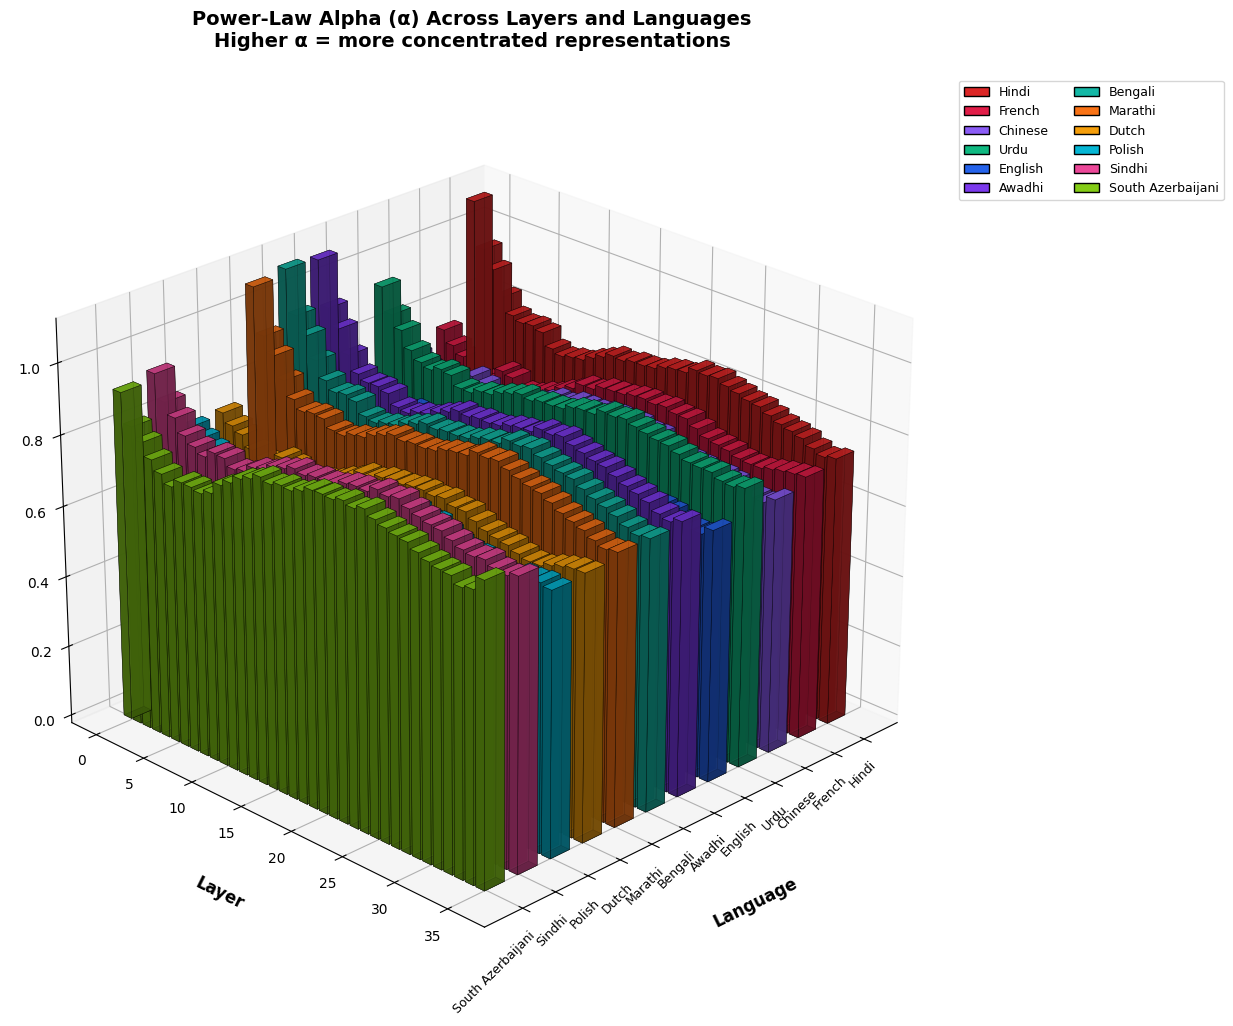

In [13]:
# 3D Bar Chart with distinct per-language colors
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

lang_codes = list(alpha_scores.keys())
bar_width = 0.6

for lang_idx, lang_code in enumerate(lang_codes):
    color = LANGUAGE_COLORS.get(lang_code, '#333333')
    alphas = alpha_scores[lang_code]
    
    for layer_idx, alpha in enumerate(alphas):
        ax.bar3d(lang_idx, layer_idx, 0, bar_width, 0.8, alpha,
                color=color, alpha=0.85, edgecolor='black', linewidth=0.3)

ax.set_xlabel('\nLanguage', fontsize=12, fontweight='bold', labelpad=20)
ax.set_ylabel('\nLayer', fontsize=12, fontweight='bold', labelpad=15)
ax.set_zlabel('\nPower-Law α', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Power-Law Alpha (α) Across Layers and Languages\n'
             'Higher α = more concentrated representations', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(np.arange(len(lang_codes)) + bar_width/2)
ax.set_xticklabels([LANGUAGES[lc] for lc in lang_codes], rotation=45, ha='right', fontsize=9)
ax.view_init(elev=25, azim=45)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=LANGUAGE_COLORS.get(lc, '#333'), edgecolor='black', 
                         label=LANGUAGES[lc]) for lc in lang_codes]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('power_law_alpha_3d.png', dpi=300, bbox_inches='tight')
plt.show()

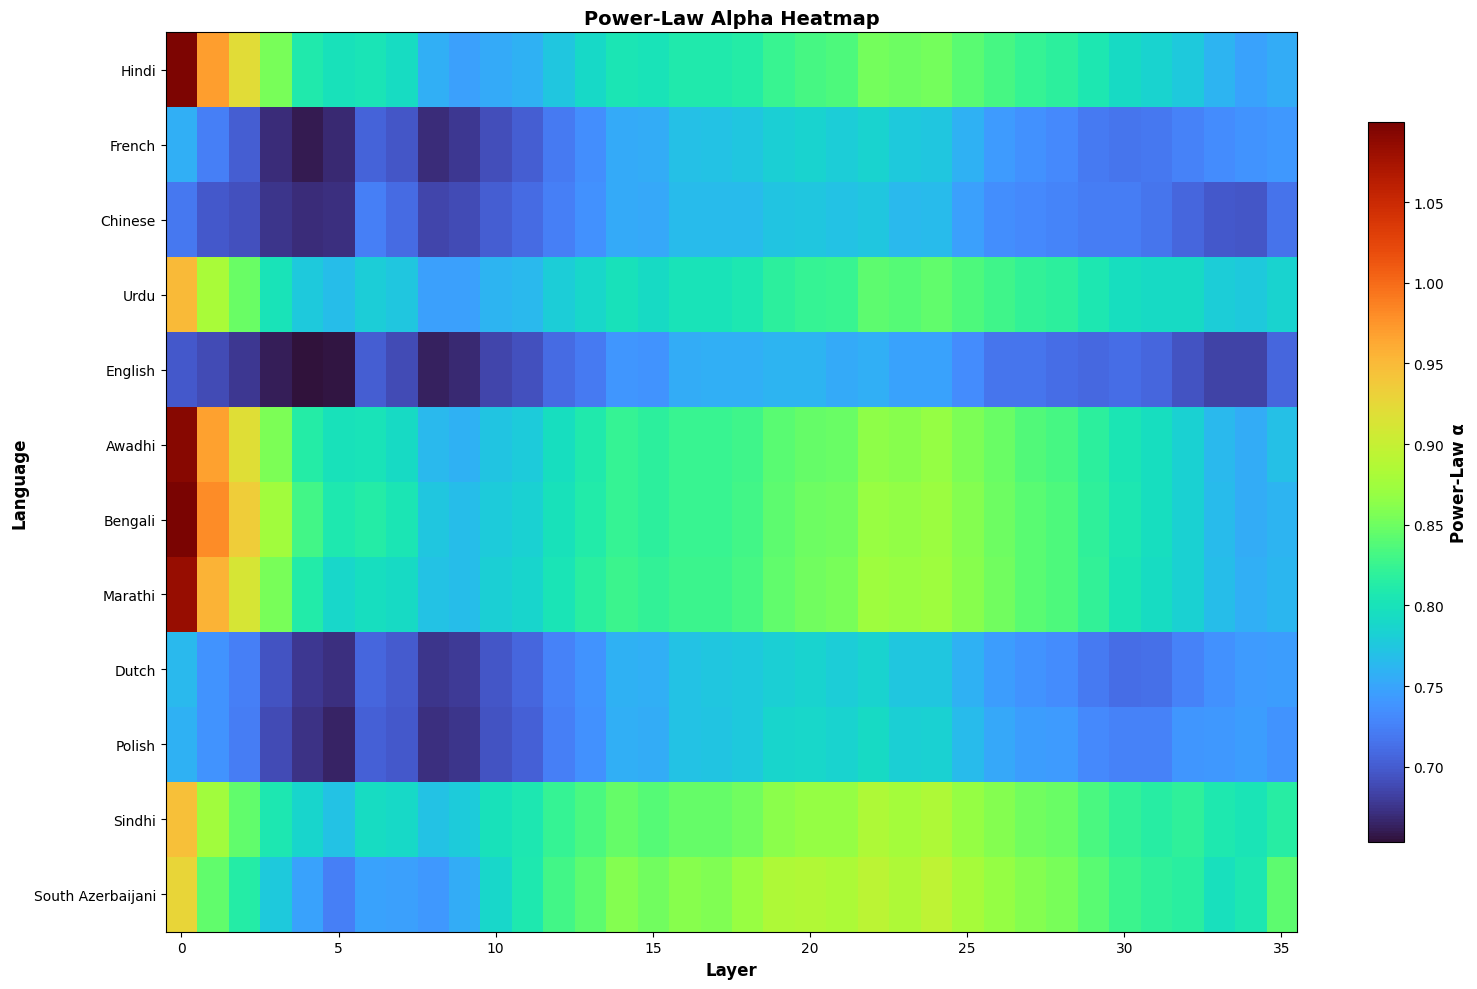

In [14]:
# Heatmap visualization
data = np.array([alpha_scores[lc] for lc in lang_codes])

fig, ax = plt.subplots(figsize=(16, 10))
im = ax.imshow(data, aspect='auto', cmap='turbo', interpolation='nearest')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Power-Law α', fontsize=12, fontweight='bold')

ax.set_yticks(np.arange(len(lang_codes)))
ax.set_yticklabels([f"{LANGUAGES[lc]}" for lc in lang_codes], fontsize=10)
ax.set_xlabel('Layer', fontsize=12, fontweight='bold')
ax.set_ylabel('Language', fontsize=12, fontweight='bold')
ax.set_title('Power-Law Alpha Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('power_law_alpha_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

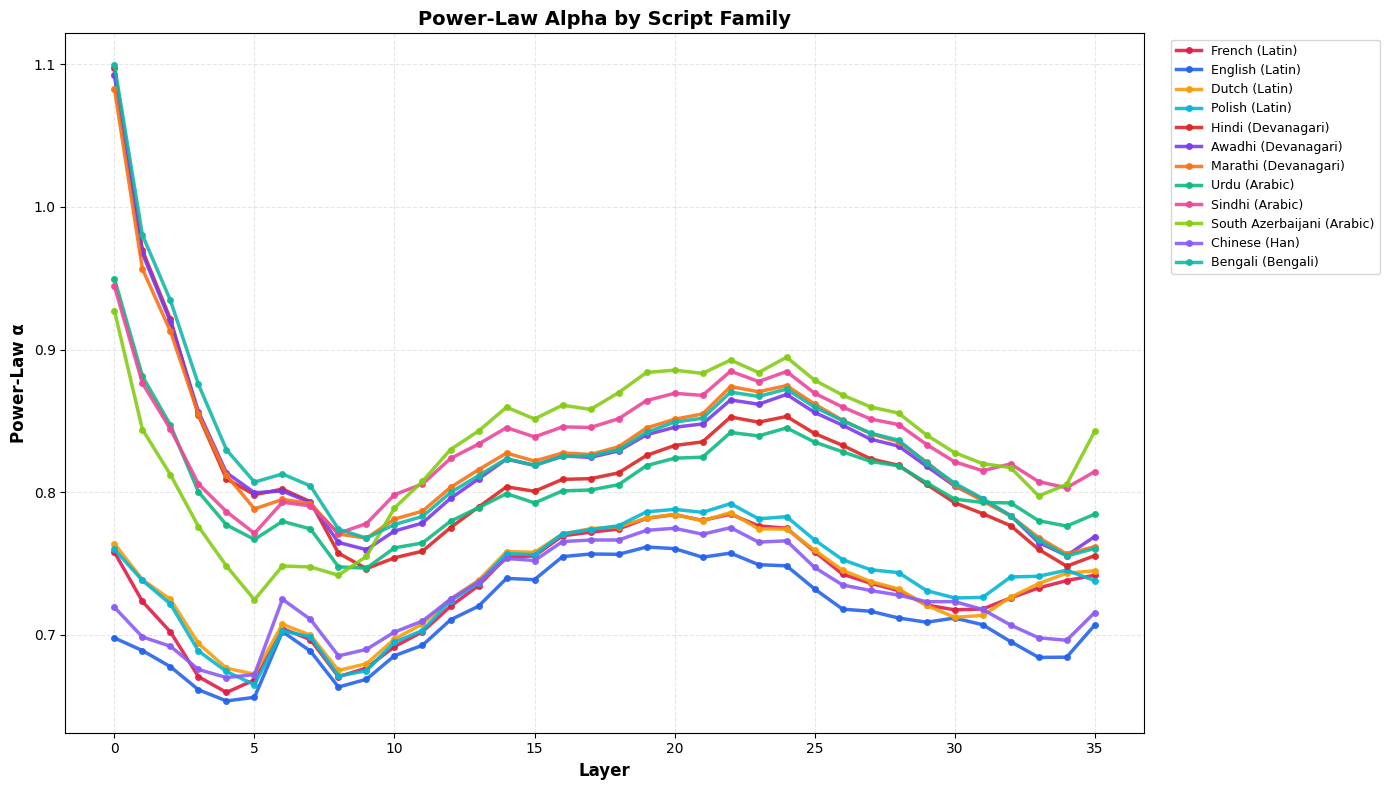

In [15]:
# Line plot by script family (each language in its own distinct color)
fig, ax = plt.subplots(figsize=(14, 8))

for script, langs in script_groups.items():
    for lang_code in langs:
        if lang_code in alpha_scores:
            ax.plot(range(n_layers), alpha_scores[lang_code], 
                   label=f"{LANGUAGES[lang_code]} ({script})", 
                   color=LANGUAGE_COLORS.get(lang_code, '#333'),
                   linewidth=2.5, marker='o', markersize=4, alpha=0.9)

ax.set_xlabel('Layer', fontsize=12, fontweight='bold')
ax.set_ylabel('Power-Law α', fontsize=12, fontweight='bold')
ax.set_title('Power-Law Alpha by Script Family', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('power_law_alpha_lines.png', dpi=300, bbox_inches='tight')
plt.show()

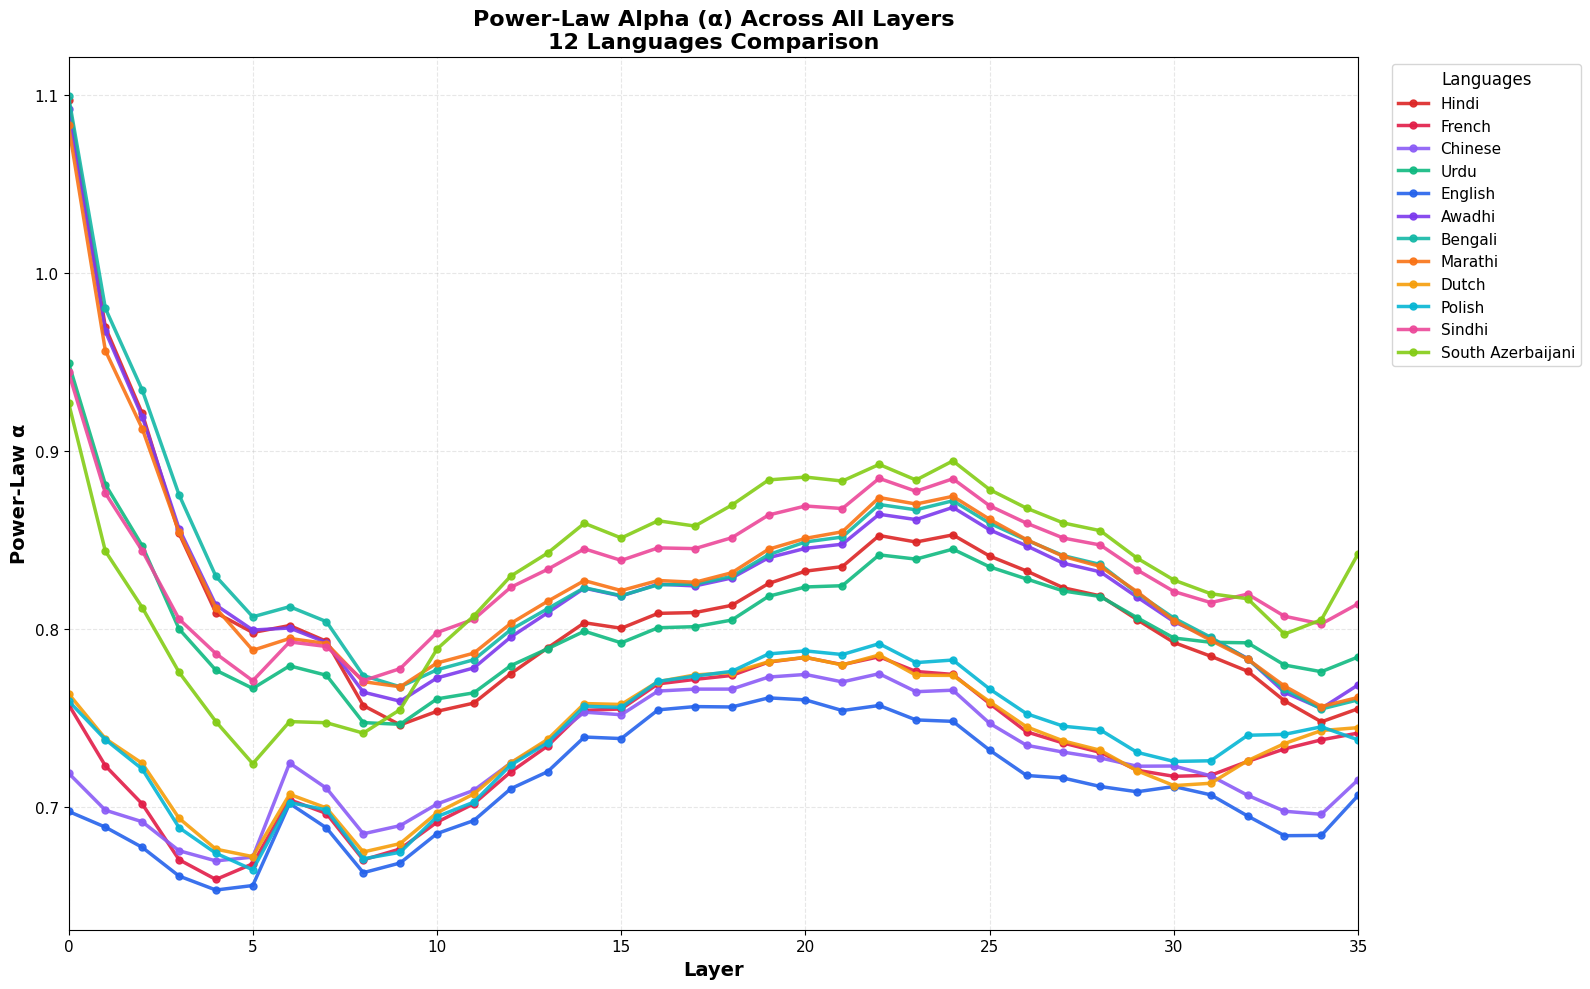

In [16]:
# Line Chart - Power Law Alpha for All 12 Languages (distinct colors)
fig, ax = plt.subplots(figsize=(16, 10))

for lang_code, alphas in alpha_scores.items():
    ax.plot(range(n_layers), alphas, 
            label=LANGUAGES[lang_code], 
            color=LANGUAGE_COLORS.get(lang_code, '#333'),
            linewidth=2.5, 
            marker='o', 
            markersize=5, 
            alpha=0.9)

ax.set_xlabel('Layer', fontsize=14, fontweight='bold')
ax.set_ylabel('Power-Law α', fontsize=14, fontweight='bold')
ax.set_title('Power-Law Alpha (α) Across All Layers\n12 Languages Comparison', 
             fontsize=16, fontweight='bold')
ax.set_xlim(0, n_layers - 1)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, title='Languages', title_fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.savefig('power_law_alpha_line_all.png', dpi=300, bbox_inches='tight')
plt.show()

## 3D Lines Plot — Layers × Languages × Power-Law Alpha

/tmp/ipykernel_24/1705960004.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


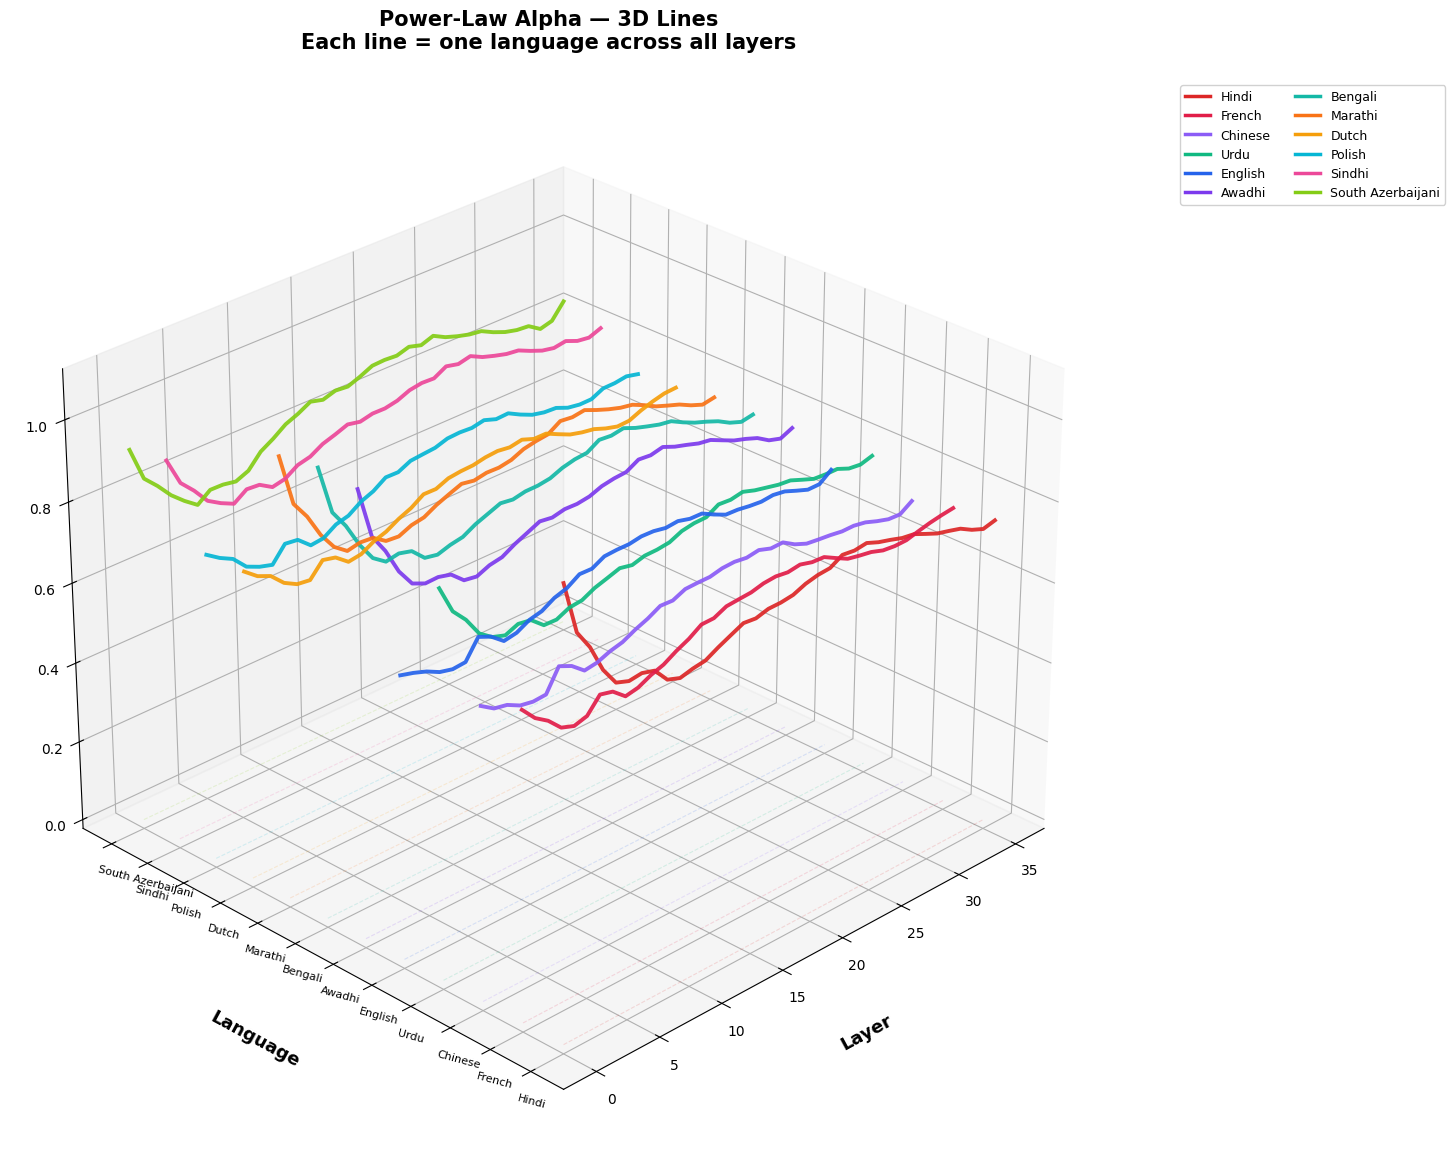

In [17]:
# ── 3D LINES PLOT (no bars, no scatter markers) ──
fig = plt.figure(figsize=(20, 14))
ax = fig.add_subplot(111, projection='3d')

lang_codes = list(alpha_scores.keys())

for lang_idx, lang_code in enumerate(lang_codes):
    color = LANGUAGE_COLORS.get(lang_code, '#333333')
    alphas = alpha_scores[lang_code]
    layers = list(range(n_layers))
    lang_positions = [lang_idx] * n_layers

    # Main line
    ax.plot(layers, lang_positions, alphas,
            color=color, linewidth=2.8, alpha=0.92,
            label=LANGUAGES[lang_code], zorder=3)

    # Subtle shadow on the floor (z=0 projection)
    ax.plot(layers, lang_positions, [0]*n_layers,
            color=color, linewidth=0.8, alpha=0.15, linestyle='--')

ax.set_xlabel('\nLayer', fontsize=13, fontweight='bold', labelpad=18)
ax.set_ylabel('\nLanguage', fontsize=13, fontweight='bold', labelpad=22)
ax.set_zlabel('\nPower-Law α', fontsize=13, fontweight='bold', labelpad=12)
ax.set_title('Power-Law Alpha — 3D Lines\n'
             'Each line = one language across all layers',
             fontsize=15, fontweight='bold', pad=22)

ax.set_yticks(range(len(lang_codes)))
ax.set_yticklabels([LANGUAGES[lc] for lc in lang_codes],
                    fontsize=8, rotation=-15, ha='left')
ax.view_init(elev=28, azim=225)

from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0], color=LANGUAGE_COLORS.get(lc,'#333'),
                         lw=2.5, label=LANGUAGES[lc]) for lc in lang_codes]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.08, 1),
          loc='upper left', fontsize=9, ncol=2,
          framealpha=0.9, edgecolor='#ccc')

plt.tight_layout()
plt.savefig('power_law_alpha_3d_lines.png', dpi=300, bbox_inches='tight')
plt.show()

## 3D Waves Plot — Layers × Languages × Power-Law Alpha

/tmp/ipykernel_24/503443440.py:63: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


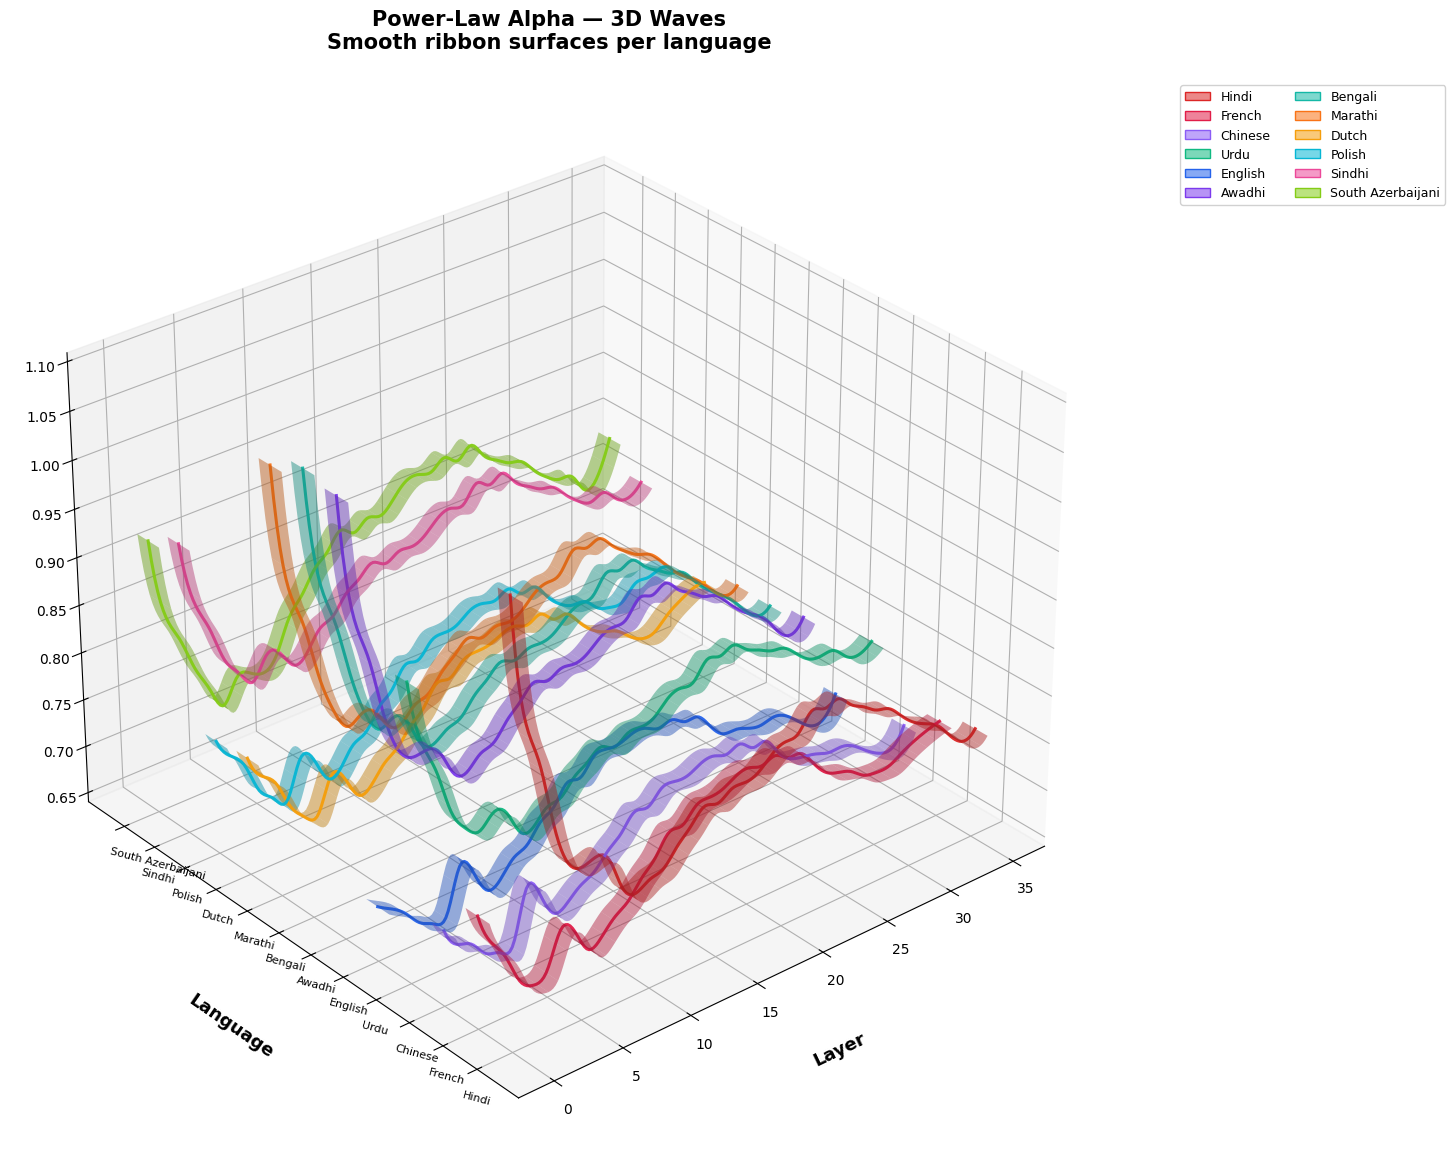

In [18]:
# ── 3D WAVES / RIBBON SURFACE PLOT ──
from matplotlib.colors import to_rgba
from scipy.interpolate import make_interp_spline

fig = plt.figure(figsize=(20, 14))
ax = fig.add_subplot(111, projection='3d')

lang_codes = list(alpha_scores.keys())
ribbon_half_width = 0.35  # half-width of each ribbon
smooth_pts = 200  # points for smooth interpolation

for lang_idx, lang_code in enumerate(lang_codes):
    color_hex = LANGUAGE_COLORS.get(lang_code, '#333333')
    face_rgba = to_rgba(color_hex, alpha=0.45)
    edge_rgba = to_rgba(color_hex, alpha=0.95)
    alphas = np.array(alpha_scores[lang_code])
    layers_raw = np.arange(n_layers)

    # Smooth the alpha curve with a cubic spline
    if n_layers >= 4:
        spline = make_interp_spline(layers_raw, alphas, k=3)
        layers_smooth = np.linspace(0, n_layers - 1, smooth_pts)
        alphas_smooth = spline(layers_smooth)
    else:
        layers_smooth = layers_raw.astype(float)
        alphas_smooth = alphas

    # Build ribbon mesh: two Y rows straddling lang_idx
    Y_lo = lang_idx - ribbon_half_width
    Y_hi = lang_idx + ribbon_half_width
    X = np.vstack([layers_smooth, layers_smooth])
    Y = np.vstack([np.full_like(layers_smooth, Y_lo),
                   np.full_like(layers_smooth, Y_hi)])
    Z = np.vstack([alphas_smooth, alphas_smooth])

    ax.plot_surface(X, Y, Z, color=face_rgba,
                    edgecolor='none', shade=True, antialiased=True)

    # Crisp top-edge line along the ribbon center
    ax.plot(layers_smooth, [lang_idx]*len(layers_smooth), alphas_smooth,
            color=edge_rgba, linewidth=2.2, zorder=5)

ax.set_xlabel('\nLayer', fontsize=13, fontweight='bold', labelpad=18)
ax.set_ylabel('\nLanguage', fontsize=13, fontweight='bold', labelpad=22)
ax.set_zlabel('\nPower-Law α', fontsize=13, fontweight='bold', labelpad=12)
ax.set_title('Power-Law Alpha — 3D Waves\n'
             'Smooth ribbon surfaces per language',
             fontsize=15, fontweight='bold', pad=22)

ax.set_yticks(range(len(lang_codes)))
ax.set_yticklabels([LANGUAGES[lc] for lc in lang_codes],
                    fontsize=8, rotation=-15, ha='left')
ax.view_init(elev=30, azim=230)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=to_rgba(LANGUAGE_COLORS.get(lc,'#333'), 0.55),
                        edgecolor=LANGUAGE_COLORS.get(lc,'#333'),
                        label=LANGUAGES[lc]) for lc in lang_codes]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.08, 1),
          loc='upper left', fontsize=9, ncol=2,
          framealpha=0.9, edgecolor='#ccc')

plt.tight_layout()
plt.savefig('power_law_alpha_3d_waves.png', dpi=300, bbox_inches='tight')
plt.show()

## 3D Scatter: Layer × Power-Law α × Sinkhorn Distance

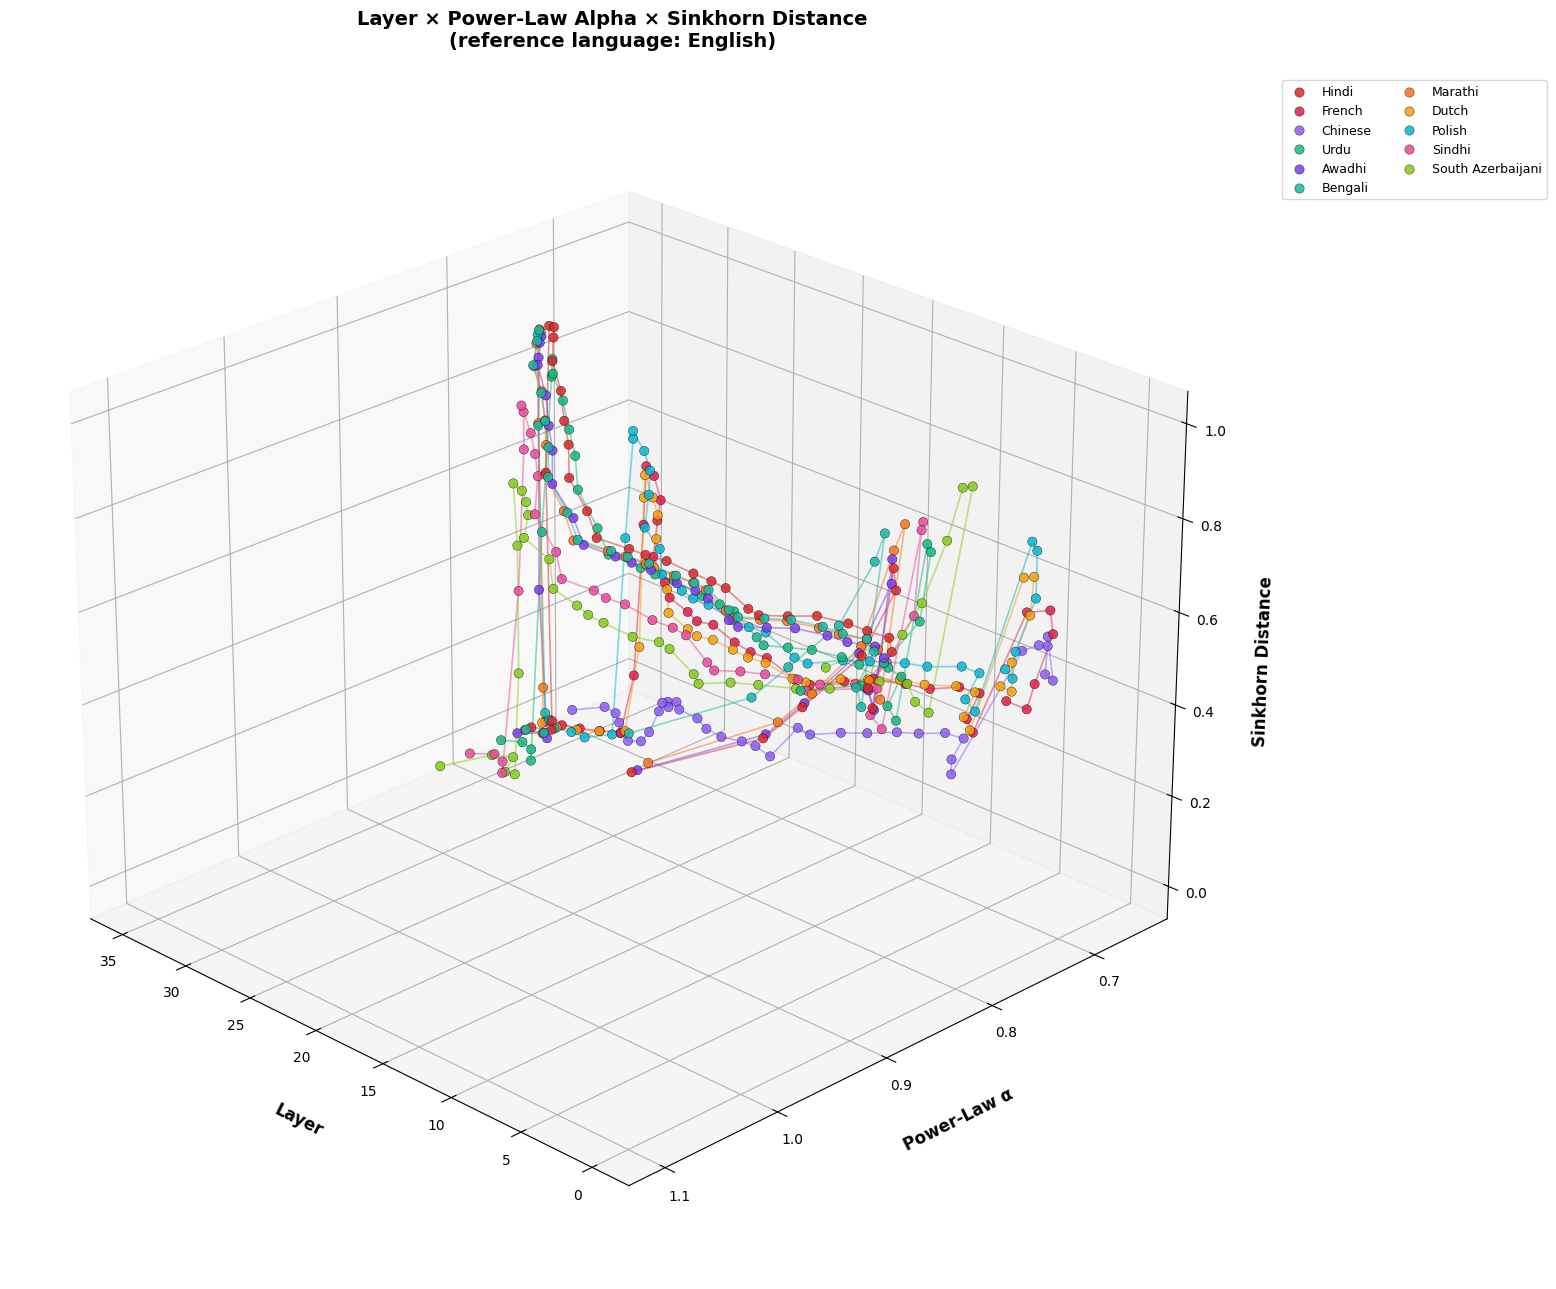

In [19]:
# 3D Scatter Plot: Layers vs Power-Law Alpha vs Sinkhorn Distance
fig = plt.figure(figsize=(18, 13))
ax = fig.add_subplot(111, projection='3d')

for lang_code in sinkhorn_scores:
    layers = list(range(n_layers))
    alphas = alpha_scores[lang_code]
    sinkhorns = sinkhorn_scores[lang_code]
    color = LANGUAGE_COLORS.get(lang_code, '#333333')
    ax.scatter(layers, alphas, sinkhorns,
               label=LANGUAGES[lang_code], color=color, s=45, alpha=0.85, edgecolors='black', linewidth=0.3)
    ax.plot(layers, alphas, sinkhorns,
            color=color, linewidth=1.2, alpha=0.5)

ax.set_xlabel('\nLayer', fontsize=12, fontweight='bold', labelpad=15)
ax.set_ylabel('\nPower-Law α', fontsize=12, fontweight='bold', labelpad=15)
ax.set_zlabel('\nSinkhorn Distance', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Layer × Power-Law Alpha × Sinkhorn Distance\n'
             '(reference language: English)', fontsize=14, fontweight='bold', pad=20)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=2)
ax.view_init(elev=25, azim=135)

plt.tight_layout()
plt.savefig('layer_alpha_sinkhorn_3d.png', dpi=300, bbox_inches='tight')
plt.show()

## Save Results

In [20]:
results = {'layer': list(range(n_layers))}
for lang_code in alpha_scores:
    results[f'{LANGUAGES[lang_code]}_alpha'] = alpha_scores[lang_code]
for lang_code in sinkhorn_scores:
    results[f'{LANGUAGES[lang_code]}_sinkhorn'] = sinkhorn_scores[lang_code]

df = pd.DataFrame(results)
df.to_csv('spinal_qwen3_4b_results_12lang.csv', index=False)
print("Results saved!")
df.head()

Results saved!


,layer,Hindi_alpha,French_alpha,Chinese_alpha,Urdu_alpha,English_alpha,Awadhi_alpha,Bengali_alpha,Marathi_alpha,Dutch_alpha,...,French_sinkhorn,Chinese_sinkhorn,Urdu_sinkhorn,Awadhi_sinkhorn,Bengali_sinkhorn,Marathi_sinkhorn,Dutch_sinkhorn,Polish_sinkhorn,Sindhi_sinkhorn,South Azerbaijani_sinkhorn
0,0,1.097202,0.757782,0.719173,0.949733,0.697679,1.092327,1.099480,1.083064,0.763809,...,0.507786,0.607060,0.722933,0.706864,0.788362,0.712139,0.545398,0.577502,0.718047,0.748341
1,1,0.969612,0.723277,0.698348,0.881313,0.688813,0.967396,0.980267,0.956513,0.738528,...,0.442589,0.479382,0.652321,0.638284,0.727245,0.652177,0.495989,0.523460,0.641765,0.721295
2,2,0.921251,0.701854,0.691853,0.846903,0.677472,0.919452,0.934435,0.912759,0.724668,...,0.462800,0.473666,0.652661,0.641394,0.731102,0.653957,0.531899,0.552129,0.650647,0.743772
3,3,0.853841,0.670530,0.675574,0.800159,0.661342,0.856475,0.875519,0.854598,0.693800,...,0.527262,0.506194,0.681276,0.670241,0.746649,0.683305,0.590161,0.621655,0.698303,0.827792
4,4,0.809281,0.659420,0.669857,0.776979,0.653488,0.813584,0.829714,0.811917,0.676452,...,0.555292,0.490145,0.793150,0.761581,0.823318,0.829649,0.644437,0.698105,0.847985,0.900949


In [21]:
# Cleanup
extractor.cleanup()
gc.collect()
torch.cuda.empty_cache()
print("Done!")

Done!
